# Final Project – California Housing Price Prediction
**Group:** [Your group name]  
**Dataset:** California Housing Prices (1990 census)  
**Date:** [Insert date]

---

## Problem Statement

The goal of this project is to predict the median house value for districts in California using a set of demographic and geographic features. This is a **regression** problem, meaning the output we're trying to predict is a continuous number (a price in dollars), not a category.

We picked this dataset because the features are intuitive and easy to interpret — things like household income, number of rooms, population density, and how close a district is to the ocean. It also has some real-world messiness (missing values, skewed distributions, an artificial value cap) that forces us to go through a proper data science pipeline rather than just plugging numbers into a model.

## Dataset Description

The data comes from the 1990 California census and was adapted by Pace and Barry (1997). It’s available on Kaggle. Each row represents a **census block group**, which is basically a small neighborhood of roughly 600 to 3,000 people.

- **Size:** 20,640 rows and 10 columns
- **Features (9):**
  - `longitude`, `latitude` — geographic coordinates of the district
  - `housing_median_age` — median age of houses in the district (years)
  - `total_rooms`, `total_bedrooms` — total counts for the **entire district**, not per house
  - `population`, `households` — how many people and households live in the district
  - `median_income` — median household income (in tens of thousands of dollars)
  - `ocean_proximity` — categorical variable with 5 values: `<1H OCEAN`, `INLAND`, `NEAR OCEAN`, `NEAR BAY`, `ISLAND`
- **Target:** `median_house_value` — the median house price in the district (US dollars)

## Assumptions and Known Limitations

Before starting the analysis, there are a few things we need to keep in mind about this data:

1. **Value cap at $500,001.** About 5% of districts hit this ceiling. The real values could be much higher, but the census just cut them off there. This means our model will never be great at predicting very expensive districts, because the training labels are essentially wrong for those rows.
2. **Age cap at 52 years.** Similarly, `housing_median_age` maxes out at 52. All districts with older houses show up as 52, which hides the real variation.
3. **District-level aggregates.** These are neighborhood averages, not individual house records. When we say “predict house prices” we really mean “predict the median price in a whole neighborhood.”
4. **1990 dollars.** The prices are not inflation-adjusted. This doesn’t affect the modeling (the relationships still hold) but the dollar amounts are in 1990 terms.
5. **Missing values are assumed random.** We assume the 207 missing values in `total_bedrooms` are missing at random and don’t introduce systematic bias.

## Project Outline

1. Data Loading & Inspection
2. Data Preprocessing (cleaning, outliers, feature engineering, encoding, scaling)
3. Exploratory Data Analysis (visual + statistical)
4. Model Training (multiple algorithms, cross-validation)
5. Evaluation & Model Comparison
6. Best Model Deep Dive (feature importance, residuals)
7. Summary & Conclusions

In [4]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

os.makedirs('plots', exist_ok=True)

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('viridis')
plt.rcParams['figure.dpi'] = 150
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.size'] = 12

print('='*80)
print('FINAL PROJECT: CALIFORNIA HOUSING PRICE PREDICTION')
print('='*80)
print('\n\u2705 Libraries loaded.')


FINAL PROJECT: CALIFORNIA HOUSING PRICE PREDICTION

✅ Libraries loaded.


---
## 1. Data Loading & First Inspection

The first step in any data science project is loading the data and taking a quick look at it. This tells us how big the dataset is, what columns we have, what types they are, and whether there are any obvious problems right away. It’s like opening a box and checking all the parts are there before you start building something.

In [ ]:
# Load dataset
df = pd.read_csv(r'../data/raw/housing.csv')
print(f'Dataset loaded: {df.shape[0]:,} rows, {df.shape[1]} columns')
df.head(10)


FileNotFoundError: [Errno 2] No such file or directory: './data/raw/housing.csv'

In [ ]:
# Data types and non-null counts
df.info()

NameError: name 'df' is not defined

In [ ]:
# Basic statistics for every numeric column
df.describe().round(2)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.00,20640.00,20640.00,20640.00,20433.00,20640.00,20640.00,20640.00,20640.00
mean,-119.57,35.63,28.64,2635.76,537.87,1425.48,499.54,3.87,206855.82
std,2.00,2.14,12.59,2181.62,421.39,1132.46,382.33,1.90,115395.62
min,-124.35,32.54,1.00,2.00,1.00,3.00,1.00,0.50,14999.00
25%,-121.80,33.93,18.00,1447.75,296.00,787.00,280.00,2.56,119600.00
50%,-118.49,34.26,29.00,2127.00,435.00,1166.00,409.00,3.53,179700.00
75%,-118.01,37.71,37.00,3148.00,647.00,1725.00,605.00,4.74,264725.00
max,-114.31,41.95,52.00,39320.00,6445.00,35682.00,6082.00,15.00,500001.00


---
## 2. Data Preprocessing

Before we can train any model, the data needs to be cleaned and prepared. Raw real-world data almost always has problems — missing values, extreme outliers, features on different scales, text columns that models can’t read. This section covers every step we took and explains why we made each decision.

### 2.1 Handling Missing Values

Missing data is one of the most common problems in real datasets. We need to find out which columns have gaps, how much is missing, and decide what to do about it. The main options are:

- **Drop the rows:** Simple, but wastes data for no good reason if only a small amount is missing.
- **Fill with the mean:** Uses the average, but the mean gets pulled around by extreme values in skewed data.
- **Fill with the median:** More robust to outliers and skew. Represents the “typical” value better.

We also check for duplicate rows, which could bias the model if the same district appears multiple times.

In [ ]:
print("="*80)
print("2. DATA PREPROCESSING")
print("="*80)

print("\n--- 2.1 Handling Missing Values ---")

# Check missing values BEFORE handling
missing_before = df.isnull().sum()
print("Missing values before handling:")
print(missing_before[missing_before > 0])
print(f"\nTotal rows: {len(df):,}")
print(f"Rows with missing data: {df.isnull().any(axis=1).sum()} ({df.isnull().any(axis=1).sum()/len(df)*100:.1f}%)")

# Fill total_bedrooms with median
median_bed = df['total_bedrooms'].median()
df['total_bedrooms'].fillna(median_bed, inplace=True)
print(f"\n\u2705 Filled {missing_before['total_bedrooms']} missing 'total_bedrooms' with median = {median_bed:.0f}")
print(f"   We chose median over mean because total_bedrooms is right-skewed.")
print(f"   The mean would be inflated by a few very large districts.")

# Verify
print(f"\n\u2705 Missing values after handling: {df.isnull().sum().sum()}")

# Duplicates
duplicates = df.duplicated().sum()
print(f"\u2705 Duplicate rows found: {duplicates}")

2. DATA PREPROCESSING

--- 2.1 Handling Missing Values ---
Missing values before handling:
total_bedrooms    207
dtype: int64

Total rows: 20,640
Rows with missing data: 207 (1.0%)

✅ Filled 207 missing 'total_bedrooms' with median = 435
   We chose median over mean because total_bedrooms is right-skewed.
   The mean would be inflated by a few very large districts.

✅ Missing values after handling: 0
✅ Duplicate rows found: 0


### 2.2 Feature Engineering

This is one of the most important steps in the whole project. The raw columns `total_rooms`, `total_bedrooms`, and `population` are **totals for the entire district**. But districts vary a lot in size — some have 200 households, others have 6,000.

A district with 10,000 total rooms sounds huge, but if it has 5,000 households, that’s only 2 rooms per home (tiny apartments). Another district with 2,000 total rooms and 100 households has 20 rooms per home (mansions). The raw totals hide this completely.

So we created three new **ratio features** that normalize for district size:

| New Feature | Formula | What it captures |
|---|---|---|
| `rooms_per_household` | total_rooms / households | How spacious the homes are on average |
| `bedrooms_per_household` | total_bedrooms / households | Average number of bedrooms per home |
| `population_per_household` | population / households | How crowded each household is |

These ratios are more meaningful than the raw counts and give the model better signal to work with. This is what’s called **domain-informed feature engineering** — we’re using our understanding of the real world (houses have rooms, people live in households) to create features that make sense.

In [ ]:
print("--- 2.2 Feature Engineering ---")

df['rooms_per_household'] = df['total_rooms'] / (df['households'] + 1e-5)
df['bedrooms_per_household'] = df['total_bedrooms'] / (df['households'] + 1e-5)
df['population_per_household'] = df['population'] / (df['households'] + 1e-5)

print("\u2705 Created 3 new ratio features:")
print("   - rooms_per_household")
print("   - bedrooms_per_household")
print("   - population_per_household")

# Check correlations of new features with target
print("\nCorrelation of new features with median_house_value:")
new_feats = ['rooms_per_household', 'bedrooms_per_household', 'population_per_household']
for f in new_feats:
    r = df[f].corr(df['median_house_value'])
    print(f"   {f:30s}: r = {r:+.3f}")

print("\nNew feature statistics:")
df[new_feats].describe().round(2)

--- 2.2 Feature Engineering ---
✅ Created 3 new ratio features:
   - rooms_per_household
   - bedrooms_per_household
   - population_per_household

Correlation of new features with median_house_value:
   rooms_per_household           : r = +0.152
   bedrooms_per_household        : r = -0.046
   population_per_household      : r = -0.024

New feature statistics:


,rooms_per_household,bedrooms_per_household,population_per_household
count,20640.00,20640.00,20640.00
mean,5.43,1.10,3.07
std,2.47,0.52,10.39
min,0.85,0.12,0.69
25%,4.44,1.01,2.43
50%,5.23,1.05,2.82
75%,6.05,1.10,3.28
max,141.91,34.07,1243.33


### 2.3 Outlier Detection and Removal

Outliers are extreme values that can distort the training process. Some outliers are real (a genuinely expensive district), but others are data errors or artifacts that don’t represent anything meaningful.

We need to be careful here — we don’t want to throw away good data, but we also don’t want one crazy row pulling the whole model off track.

**What we DON’T remove:**
- The $500k cap — that’s a known data limitation, not an outlier
- The age cap at 52 — same thing
- Expensive or large districts — those are real

**What we DO remove:**
- Districts with 141 rooms per household (clearly a data error)
- Districts with 1,200+ people per household (impossible)
- Any value that falls far outside the normal range using the IQR method

We use the **IQR method** with a threshold of 3x IQR. This is a conservative threshold that only catches truly extreme values. The IQR (Interquartile Range) is the range between the 25th and 75th percentiles. Anything more than 3 times that range below Q1 or above Q3 gets flagged.

In [ ]:
print("--- 2.3 Outlier Detection ---")
print(f"Rows before outlier removal: {len(df):,}")

# Check the engineered features for obvious problems
print("\nSuspicious values in engineered features:")
print(f"  rooms_per_household      max: {df['rooms_per_household'].max():.1f}  (141 rooms per home? clearly wrong)")
print(f"  population_per_household max: {df['population_per_household'].max():.1f}  (1200+ people per home? impossible)")

# IQR method on key columns including the new ratio features
outlier_cols = ['total_rooms', 'total_bedrooms', 'population', 'households',
                'median_income', 'rooms_per_household', 'bedrooms_per_household',
                'population_per_household']

print("\nOutlier detection (IQR method, threshold = 3x IQR):")
outlier_mask = pd.Series(False, index=df.index)

for col in outlier_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 3 * IQR
    upper = Q3 + 3 * IQR
    col_outliers = (df[col] < lower) | (df[col] > upper)
    n = col_outliers.sum()
    if n > 0:
        print(f"  {col:30s}: {n:4d} outliers  (valid range: {lower:,.1f} to {upper:,.1f})")
    outlier_mask = outlier_mask | col_outliers

print(f"\nTotal rows flagged: {outlier_mask.sum()} ({outlier_mask.sum()/len(df)*100:.1f}%)")

df = df[~outlier_mask].copy()
print(f"\u2705 Rows after outlier removal: {len(df):,}")
print(f"   Removed {outlier_mask.sum()} extreme rows.")

--- 2.3 Outlier Detection ---
Rows before outlier removal: 20,640

Suspicious values in engineered features:
  rooms_per_household      max: 141.9  (141 rooms per home? clearly wrong)
  population_per_household max: 1243.3  (1200+ people per home? impossible)

Outlier detection (IQR method, threshold = 3x IQR):
  total_rooms                   :  494 outliers  (valid range: -3,653.0 to 8,248.8)
  total_bedrooms                :  456 outliers  (valid range: -741.8 to 1,682.0)
  population                    :  421 outliers  (valid range: -2,027.0 to 4,539.0)
  households                    :  415 outliers  (valid range: -695.0 to 1,580.0)
  median_income                 :  140 outliers  (valid range: -4.0 to 11.3)
  rooms_per_household           :  180 outliers  (valid range: -0.4 to 10.9)
  bedrooms_per_household        :  839 outliers  (valid range: 0.7 to 1.4)
  population_per_household      :  132 outliers  (valid range: -0.1 to 5.8)

Total rows flagged: 1719 (8.3%)
✅ Rows after outl

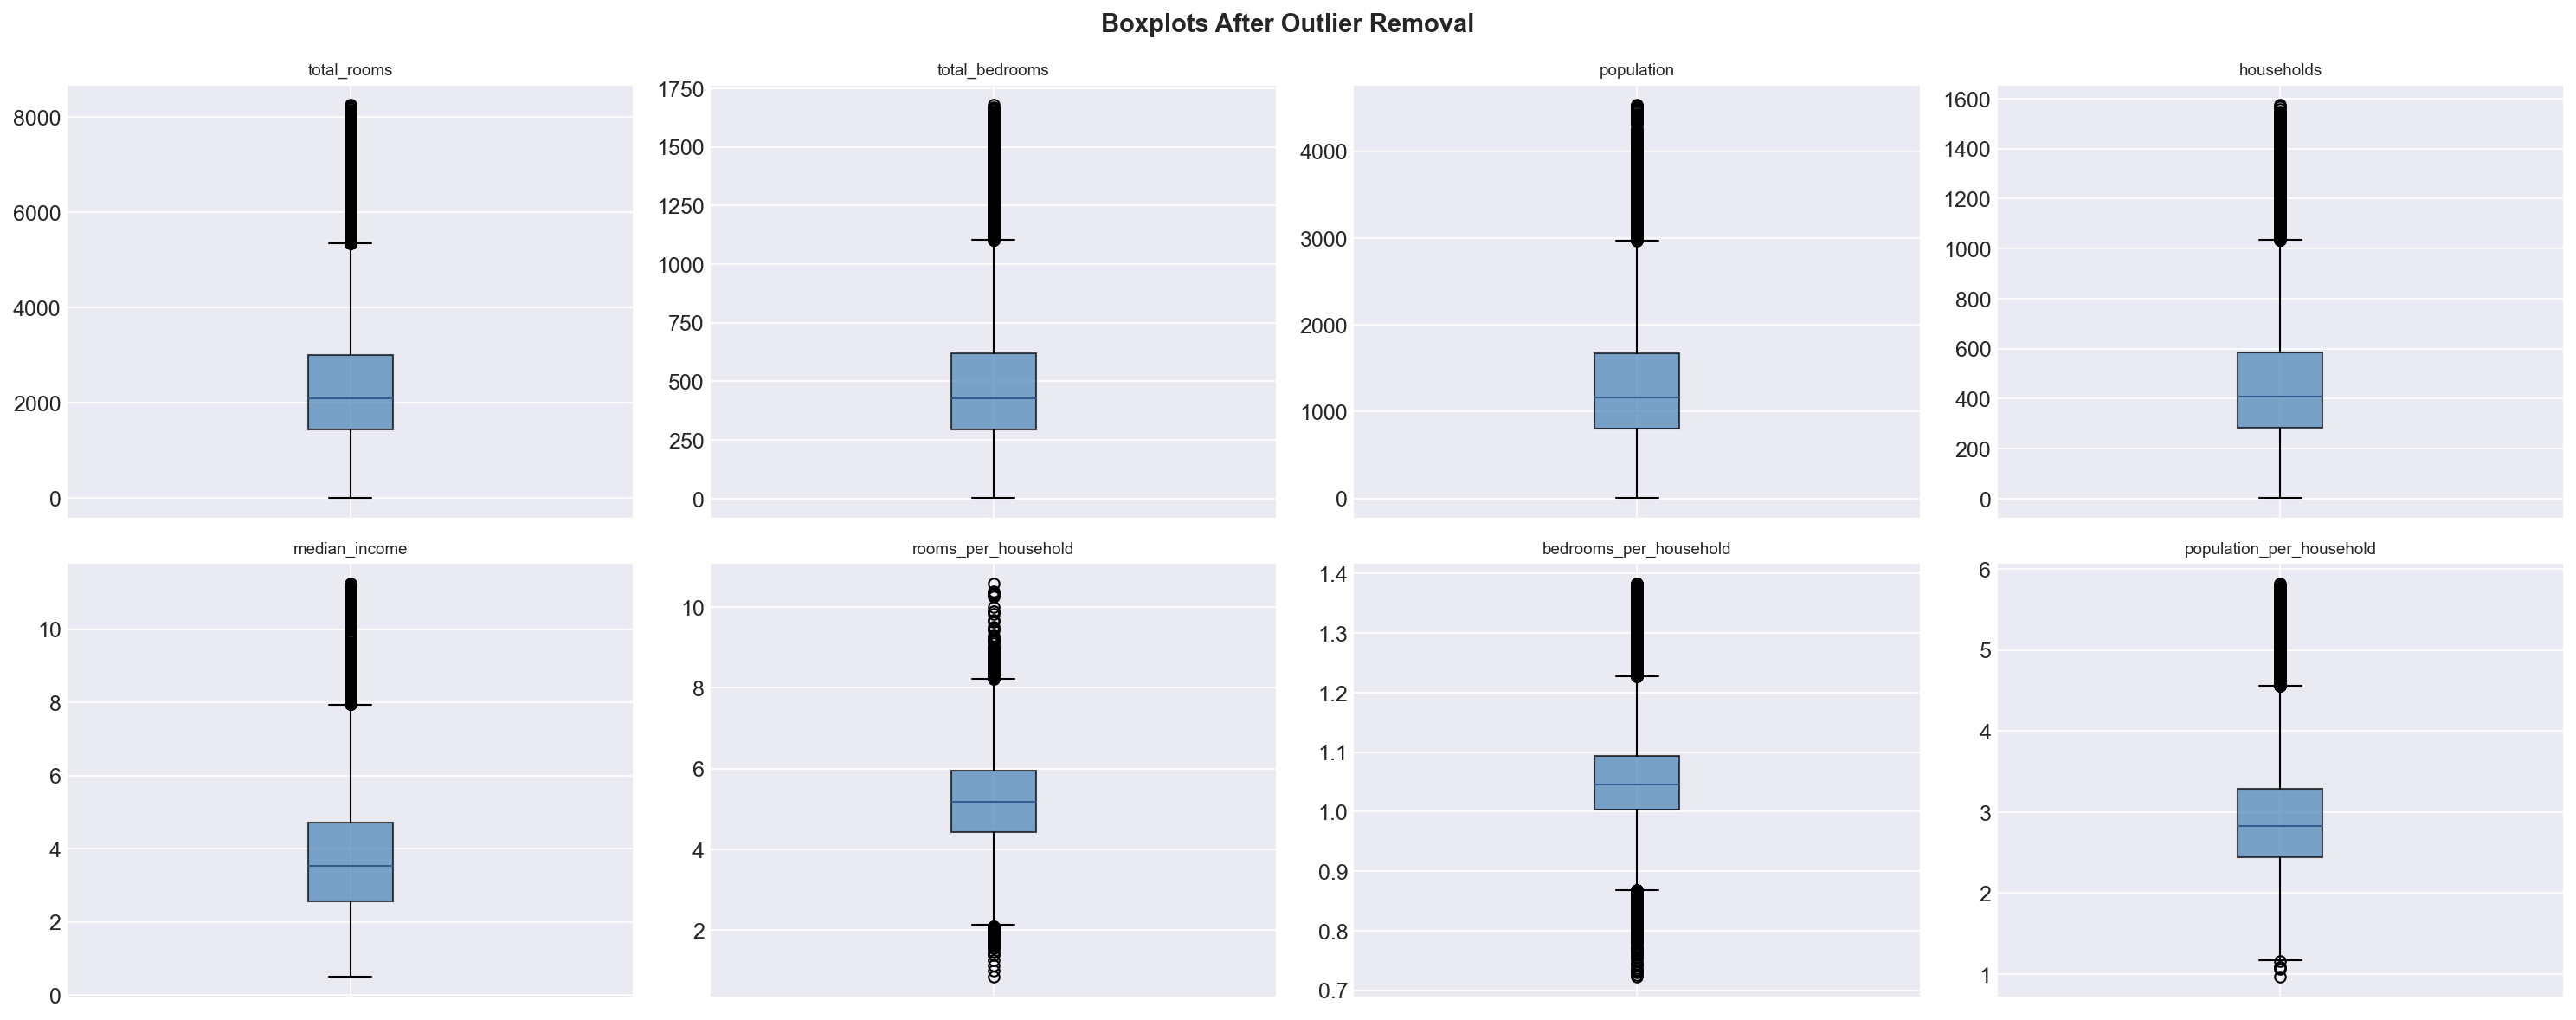

✅ Saved: plots/outlier_boxplots.png


In [ ]:
# Boxplots after cleaning to verify
fig, axes = plt.subplots(2, 4, figsize=(20, 8))
axes = axes.flatten()
for i, col in enumerate(outlier_cols):
    axes[i].boxplot(df[col].dropna(), vert=True, patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.7))
    axes[i].set_title(col, fontsize=9)
    axes[i].tick_params(axis='x', labelbottom=False)
plt.suptitle('Boxplots After Outlier Removal', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/outlier_boxplots.png', dpi=300)
plt.show()
print("\u2705 Saved: plots/outlier_boxplots.png")

### 2.4 Encoding the Categorical Variable

The column `ocean_proximity` contains text values like “INLAND”, “NEAR BAY”, “NEAR OCEAN”, etc. Machine learning models can only work with numbers, so we need to convert this text into a numeric format.

There are two main approaches:

- **Label encoding:** Assign numbers like INLAND=0, NEAR BAY=1, NEAR OCEAN=2. The problem is this implies an ordering — the model would think NEAR OCEAN (2) is somehow “twice as much” as NEAR BAY (1), which doesn’t make sense.
- **One-hot encoding:** Create a separate binary (0/1) column for each category. This treats each category independently with no false ordering.

We went with **one-hot encoding** because there’s no natural order between the ocean proximity categories. We also used `drop_first=True` to drop one of the encoded columns. This avoids the “dummy variable trap” — if a district is NOT in any of the four remaining categories, it must be in the dropped one, so that column would be perfectly redundant. This redundancy can confuse linear models.

In [ ]:
print("--- 2.4 Encoding Categorical Variable ---")

print(f"\nCategories in ocean_proximity: {df['ocean_proximity'].unique().tolist()}")
print(f"Distribution:")
print(df['ocean_proximity'].value_counts().to_string())

df = pd.get_dummies(df, columns=['ocean_proximity'], drop_first=True, dtype=int)
print(f"\n\u2705 One-hot encoded 'ocean_proximity'")
print(f"   New binary columns: {[c for c in df.columns if 'ocean' in c]}")
print(f"   Dropped one column (drop_first=True) to avoid the dummy variable trap.")

--- 2.4 Encoding Categorical Variable ---

Categories in ocean_proximity: ['NEAR BAY', '<1H OCEAN', 'INLAND', 'NEAR OCEAN', 'ISLAND']
Distribution:
ocean_proximity
<1H OCEAN     8557
INLAND        5722
NEAR OCEAN    2468
NEAR BAY      2172
ISLAND           2

✅ One-hot encoded 'ocean_proximity'
   New binary columns: ['ocean_proximity_INLAND', 'ocean_proximity_ISLAND', 'ocean_proximity_NEAR BAY', 'ocean_proximity_NEAR OCEAN']
   Dropped one column (drop_first=True) to avoid the dummy variable trap.


### 2.5 Train/Test Split and Feature Scaling

Before training any model, we need to split the data into two parts:

- **Training set (80%):** The model learns from this data.
- **Test set (20%):** We evaluate the model on this data. The model never sees it during training.

This is critical because if we trained and tested on the same data, we’d be measuring memorization, not real learning. It’s like a student who memorizes answers to a practice test — they’ll ace that exact test but fail a new one.

We use `random_state=42` to make the split reproducible. Anyone running this notebook gets the exact same split.

**Feature scaling** is also necessary because our features are on very different scales. `median_income` goes from 0.5 to 15, while `total_rooms` goes up to tens of thousands. Without scaling, distance-based models like KNN would completely ignore the small-scale features because the big numbers dominate everything. We use **StandardScaler**, which centers each feature to mean=0 and standard deviation=1.

**Important:** We fit the scaler on the training data only, then apply the same transformation to the test data. If we calculated the mean and standard deviation using the test set too, that would be **data leakage** — the model would indirectly have seen information about the test set, and our evaluation would be unrealistically optimistic.

In [ ]:
print("--- 2.5 Train/Test Split and Scaling ---")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.drop('median_house_value', axis=1)
y = df['median_house_value']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"\u2705 Train set: {X_train.shape[0]:,} samples ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"\u2705 Test set:  {X_test.shape[0]:,} samples ({X_test.shape[0]/len(X)*100:.0f}%)")
print(f"   Total features: {X.shape[1]}")

# Sanity check: are target distributions similar?
print(f"\n   Train median price: ${y_train.median():,.0f}")
print(f"   Test median price:  ${y_test.median():,.0f}")
print(f"   (These should be close \u2014 confirms the split is fair.)")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print(f"\n\u2705 Applied StandardScaler (fit on training data only \u2014 no data leakage).")

--- 2.5 Train/Test Split and Scaling ---
✅ Train set: 15,136 samples (80%)
✅ Test set:  3,785 samples (20%)
   Total features: 15

   Train median price: $181,300
   Test median price:  $178,900
   (These should be close — confirms the split is fair.)

✅ Applied StandardScaler (fit on training data only — no data leakage).


---
## 3. Exploratory Data Analysis (EDA)

Before jumping into modeling, we spent time exploring the data visually and statistically. The goal of EDA is to understand what we’re working with, spot patterns, and form hypotheses about which features will be useful. Skipping this step is like driving blindfolded — you might get somewhere, but probably not where you want.

### 3.1 Visual Analysis

We created several plots to understand the data from different angles. All plots are saved to the `plots/` folder at 300 DPI for use in the presentation.

In [ ]:
print("="*80)
print("3. EXPLORATORY DATA ANALYSIS (EDA)")
print("="*80)
print("\n--- 3.1 Visual Analysis ---")

3. EXPLORATORY DATA ANALYSIS (EDA)

--- 3.1 Visual Analysis ---


#### Target Variable Distribution

The first thing we looked at is the variable we’re trying to predict: `median_house_value`. Understanding its distribution tells us whether it’s skewed, whether there are caps or floors, and what kind of variation we need to explain.

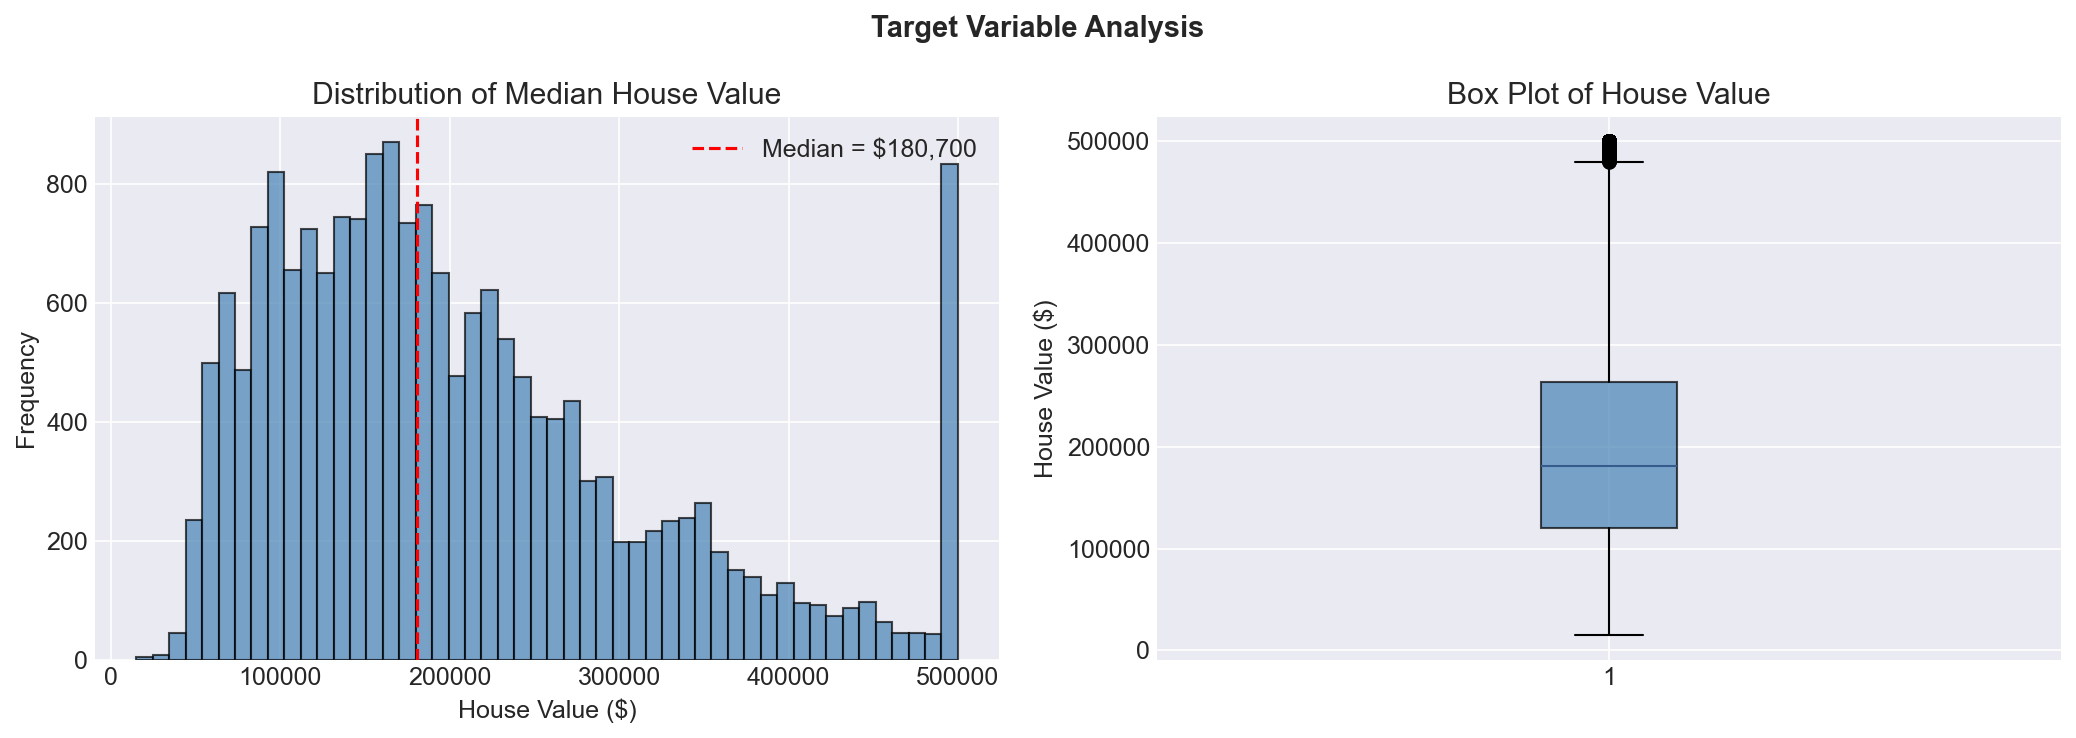

✅ Saved: plots/target_distribution.png

Values at the cap ($500,001): 771 rows (4.1%)


In [ ]:
# Plot 1: Target distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(y, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].axvline(y.median(), color='red', ls='--', label=f'Median = ${y.median():,.0f}')
axes[0].set_title('Distribution of Median House Value')
axes[0].set_xlabel('House Value ($)')
axes[0].set_ylabel('Frequency')
axes[0].legend()

axes[1].boxplot(y, vert=True, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.7))
axes[1].set_title('Box Plot of House Value')
axes[1].set_ylabel('House Value ($)')

plt.suptitle('Target Variable Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/target_distribution.png', dpi=300)
plt.show()
print("\u2705 Saved: plots/target_distribution.png")

cap_count = (df['median_house_value'] == df['median_house_value'].max()).sum()
print(f"\nValues at the cap (${df['median_house_value'].max():,.0f}): {cap_count} rows ({cap_count/len(df)*100:.1f}%)")

The distribution is right-skewed, with most districts priced between $100k and $250k and a long tail toward higher values. The spike at $500,001 confirms the census value cap. The boxplot shows upper outliers, which is normal for real estate data.

#### Ocean Proximity vs House Value

We have one categorical feature: `ocean_proximity`. Before encoding it for the model, we wanted to check if it actually carries useful information. If all categories had the same price distribution, the feature wouldn’t help.

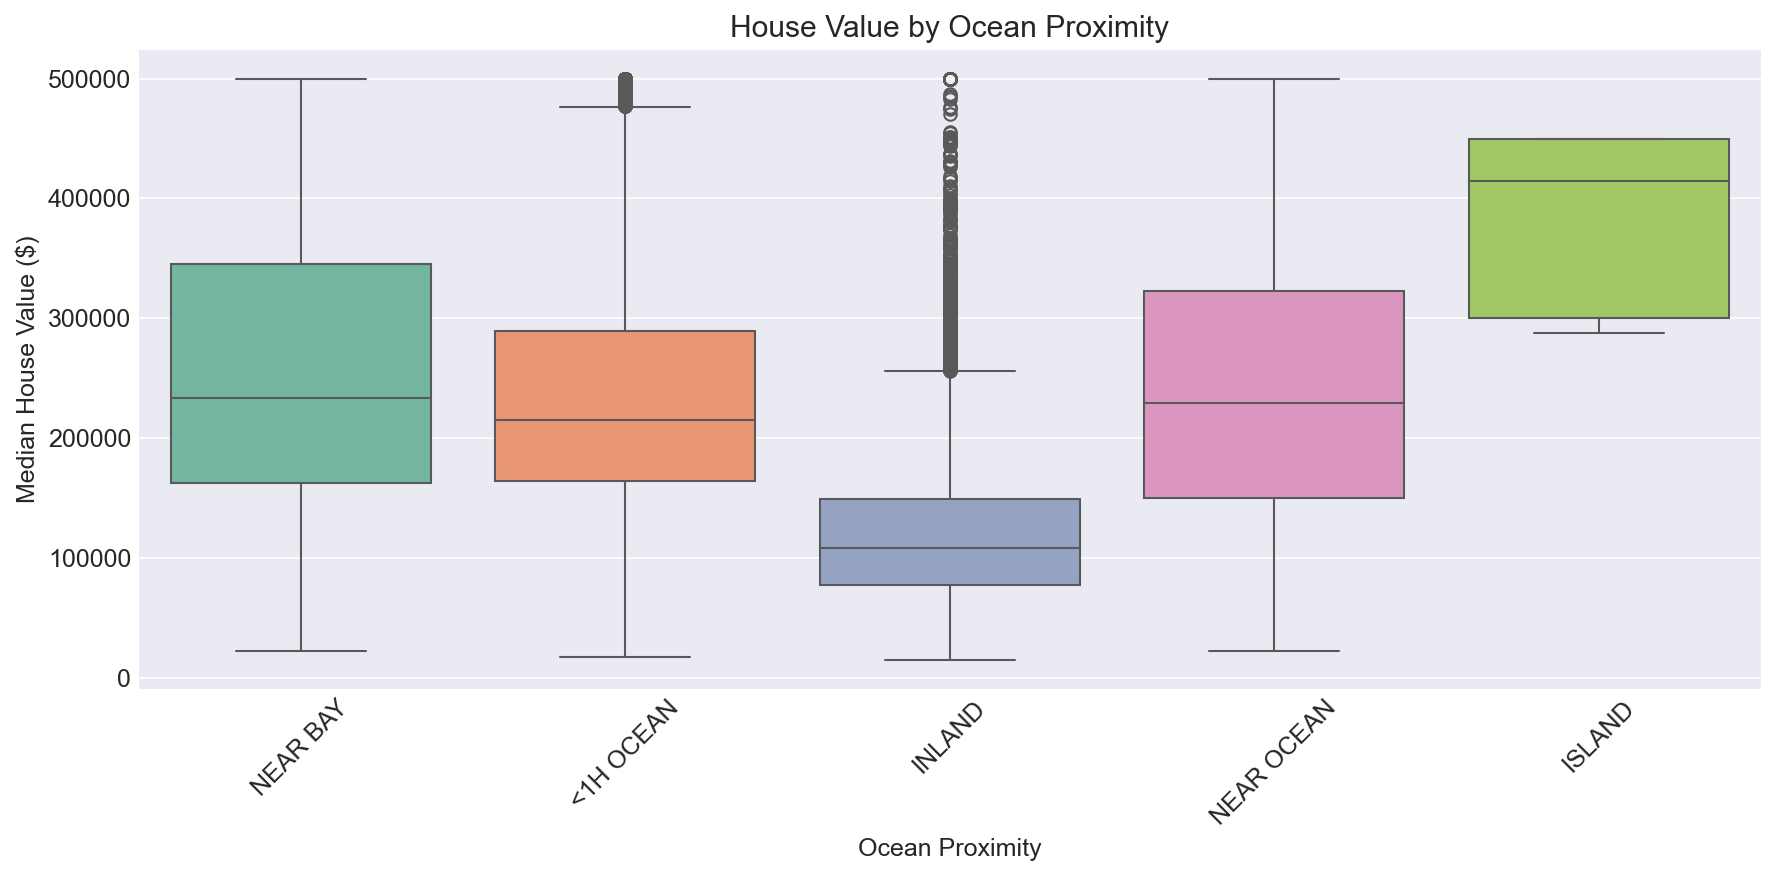

✅ Saved: plots/ocean_proximity_boxplot.png


In [ ]:
# Plot 2: Ocean proximity boxplot (using original data before encoding)
df_orig = pd.read_csv(r'../data/raw/housing.csv')
fig, ax = plt.subplots(figsize=(12, 6))
sns.boxplot(x='ocean_proximity', y='median_house_value', data=df_orig, palette='Set2')
ax.set_title('House Value by Ocean Proximity')
ax.set_xlabel('Ocean Proximity')
ax.set_ylabel('Median House Value ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('plots/ocean_proximity_boxplot.png', dpi=300)
plt.show()
print('\u2705 Saved: plots/ocean_proximity_boxplot.png')


The plot shows clear differences between categories. ISLAND districts are the most expensive (though there are only 5 of them). NEAR BAY and NEAR OCEAN are significantly pricier than INLAND. This confirms that ocean proximity is a useful feature for the model.

#### Income vs House Value

Since median_income had the highest correlation with house value in our initial inspection, we wanted to look at this relationship more carefully.

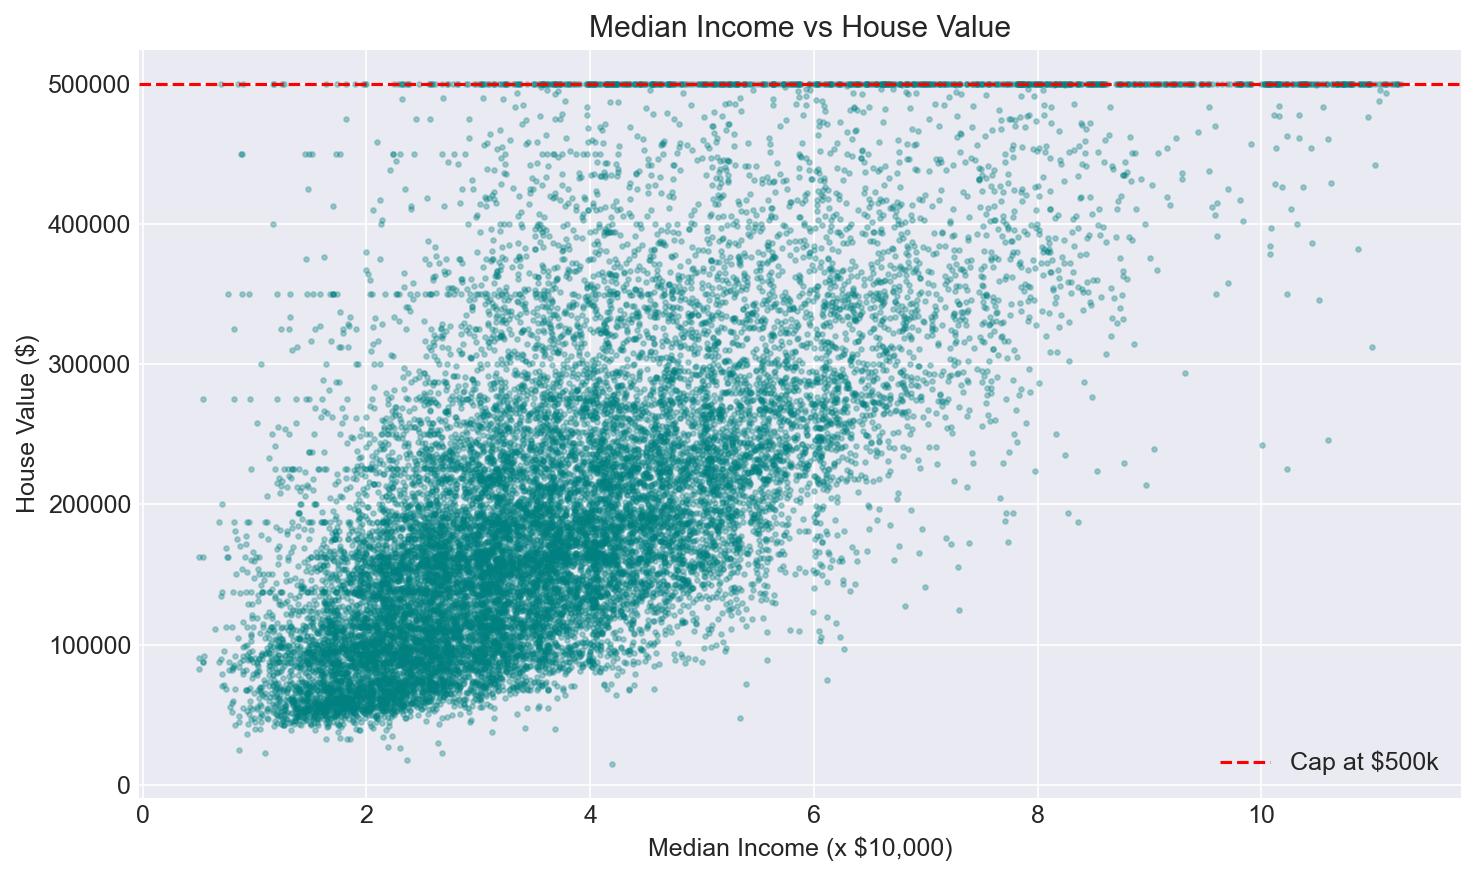

✅ Saved: plots/income_vs_value.png


In [ ]:
# Plot 3: Income vs Value
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(df['median_income'], y, alpha=0.3, s=5, c='teal')
ax.set_title('Median Income vs House Value')
ax.set_xlabel('Median Income (x $10,000)')
ax.set_ylabel('House Value ($)')
ax.axhline(500001, color='red', ls='--', label='Cap at $500k')
ax.legend()
plt.tight_layout()
plt.savefig('plots/income_vs_value.png', dpi=300)
plt.show()
print("\u2705 Saved: plots/income_vs_value.png")

There’s a clear upward trend: higher income districts have more expensive houses. Two things stand out. First, the spread gets wider as income goes up — for high-income areas, prices vary a lot, which means our model will be less confident for expensive districts. Second, the horizontal line at $500k is the value cap — those data points are essentially wrong labels and will limit the model’s accuracy in that range.

#### Geographic Distribution

Real estate is all about location. Since we have latitude and longitude, we can plot the districts on a map and color them by price to see geographic patterns.

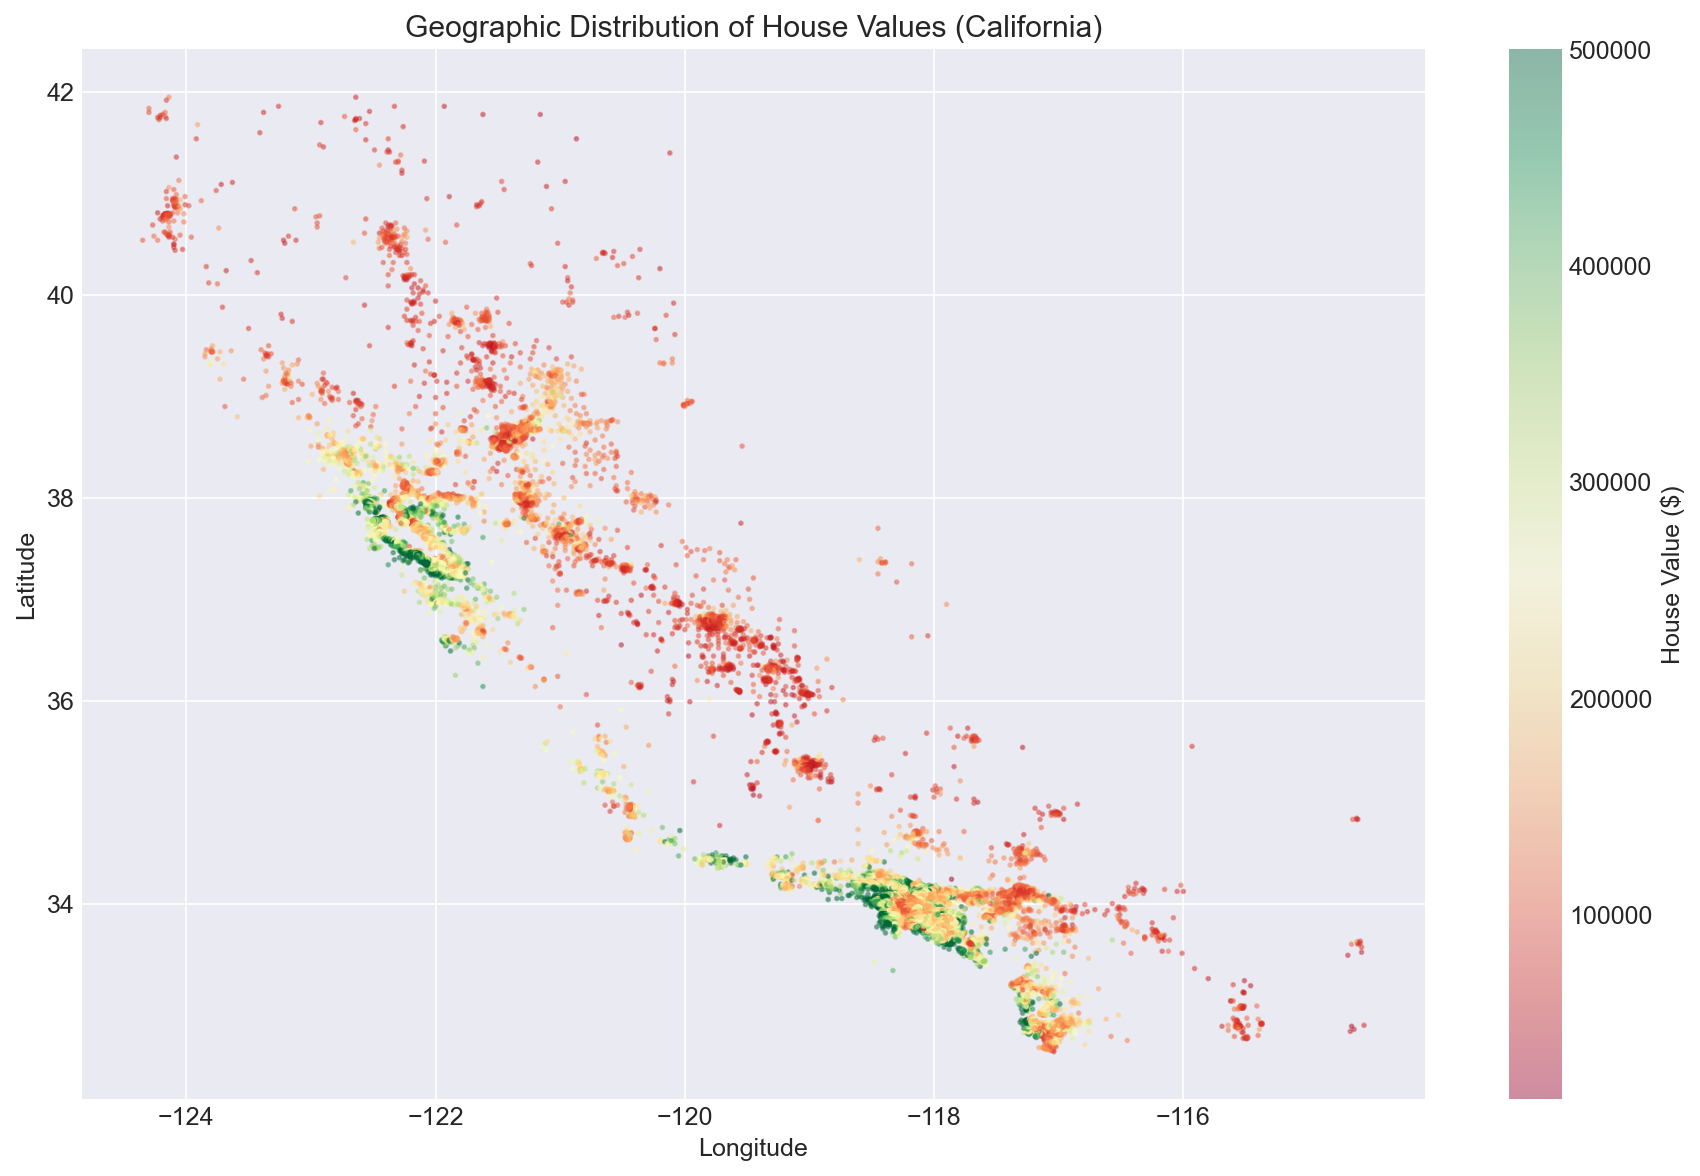

✅ Saved: plots/geographic_map.png


In [ ]:
# Plot 4: Geographic map
fig, ax = plt.subplots(figsize=(12, 8))
sc = ax.scatter(df['longitude'], df['latitude'], c=y, cmap='RdYlGn', alpha=0.4, s=3)
plt.colorbar(sc, ax=ax, label='House Value ($)')
ax.set_title('Geographic Distribution of House Values (California)')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.tight_layout()
plt.savefig('plots/geographic_map.png', dpi=300)
plt.show()
print("\u2705 Saved: plots/geographic_map.png")

Expensive districts cluster along the coast, especially around San Francisco and Los Angeles. Inland areas (the Central Valley) are consistently cheaper. This confirms that latitude and longitude carry real predictive information — they’re not just noise.

#### Correlation Analysis

We computed Pearson correlations between all numeric features to answer two questions: which features help predict house value, and which features are redundant (correlated with each other).

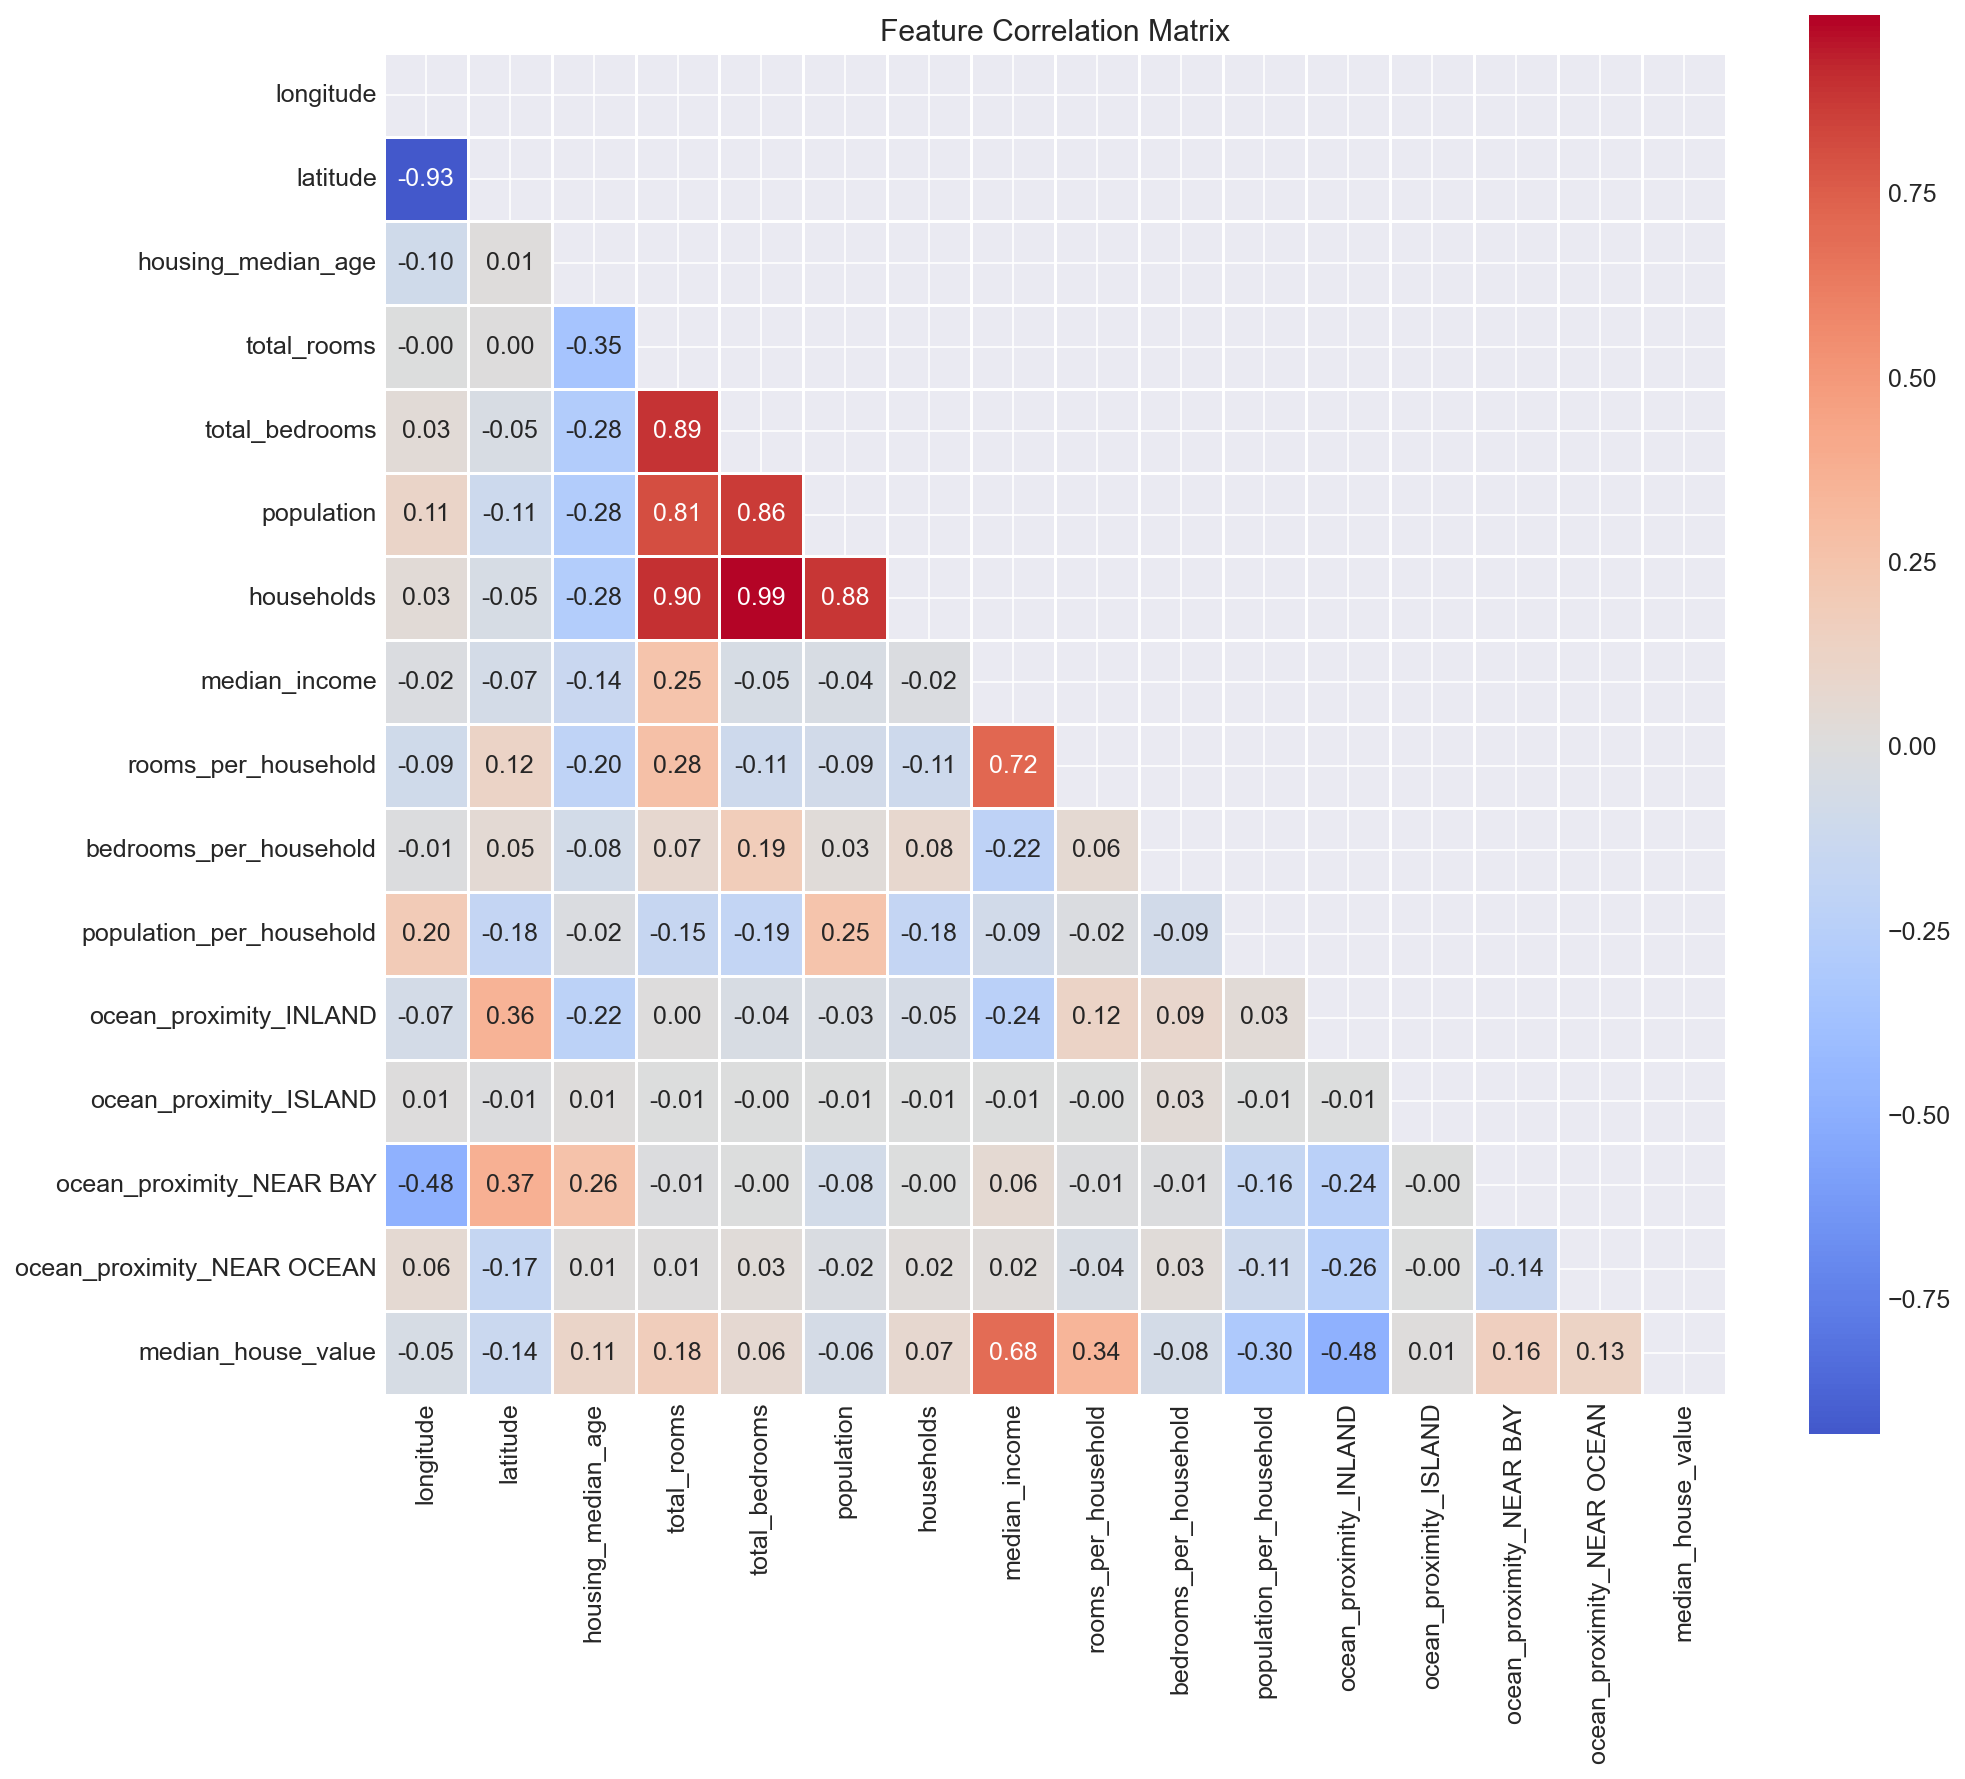

✅ Saved: plots/correlation_heatmap.png


In [ ]:
# Plot 5: Correlation heatmap
numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
corr_matrix = df[numeric_cols + ['median_house_value']].corr()
fig, ax = plt.subplots(figsize=(14, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5, ax=ax)
ax.set_title('Feature Correlation Matrix')
plt.tight_layout()
plt.savefig('plots/correlation_heatmap.png', dpi=300)
plt.show()
print("\u2705 Saved: plots/correlation_heatmap.png")

#### Pairplot

A pairplot shows the relationship between every pair of selected features at once. We picked the 5 most relevant features to keep it readable.


In [ ]:
# Focused pairplot — only the features that actually matter
key_features = ['median_income', 'rooms_per_household', 'bedrooms_per_household',
                'housing_median_age', 'median_house_value']

sns.pairplot(df[key_features], diag_kind='hist', plot_kws={'alpha': 0.3, 's': 5})
plt.suptitle('Pairplot \u2014 Key Features', y=1.02, fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/pairplot_key_features.png', dpi=300)
plt.show()
print('\u2705 Saved: plots/pairplot_key_features.png')


KeyError: "['bedrooms_per_room'] not in index"

### 3.2 Statistical Analysis

Beyond the visual plots, we also computed numerical statistics to characterize the target variable and identify which features are most strongly (and weakly) associated with house value.

In [ ]:
print("--- 3.2 Statistical Analysis ---")

print("\nTarget variable statistics:")
print(f"  Mean:     ${y.mean():,.2f}")
print(f"  Median:   ${y.median():,.2f}")
print(f"  Std Dev:  ${y.std():,.2f}")
print(f"  Skewness: {y.skew():.3f}  (positive = right-skewed)")
print(f"  Kurtosis: {y.kurtosis():.3f}  (heavy tails)")

corr_target = corr_matrix['median_house_value'].drop('median_house_value').sort_values(ascending=False)

print("\nTop 5 features correlated with house value (positive):")
for feat, val in corr_target.head(5).items():
    print(f"  {feat:30s}: {val:+.3f}")

print("\nBottom 5 features correlated with house value (negative):")
for feat, val in corr_target.tail(5).items():
    print(f"  {feat:30s}: {val:+.3f}")

The key takeaway from the statistical analysis is that **median_income** is the single strongest predictor. The positive skewness confirms the right-skewed distribution we saw in the histogram. The strong correlations between total_rooms, total_bedrooms, and households (multicollinearity) justify our decision to create ratio features instead of relying on the raw counts.

---
## 4. Model Selection and Training

Now we get to the actual machine learning part. The question is: which algorithm should we use? There are many different regression algorithms, and the truth is we don’t know in advance which one will work best on this particular dataset. Different algorithms have different strengths:

- **Linear models** (Linear Regression, Ridge, Lasso) assume a straight-line relationship between features and price. They’re fast and interpretable but miss complex patterns.
- **Distance-based models** (KNN) predict based on similar past examples. Simple but can struggle with many features.
- **Tree-based models** (Decision Tree) can capture non-linear patterns but tend to overfit (memorize the training data).
- **Ensemble models** (Random Forest, Gradient Boosting) combine many trees to reduce overfitting. Usually the top performers.

Our approach: train 7 different models from these 4 families and compare them. For each model, we use **5-fold cross-validation** on the training set. This means the training data gets split into 5 parts, the model trains on 4 and tests on the 5th, and this rotates 5 times. The average score is much more reliable than a single split because it reduces the chance of getting lucky or unlucky with the data partition.

In [ ]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score

print("="*80)
print("4. MODEL SELECTION AND TRAINING")
print("="*80)

models = {
    'Linear Regression': LinearRegression(),
    'Ridge (L2)': Ridge(alpha=1.0),
    'Lasso (L1)': Lasso(alpha=1.0),
    'KNN (k=5)': KNeighborsRegressor(n_neighbors=5),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=200, random_state=42),
}

results = []
print(f"\nTraining {len(models)} models with 5-fold cross-validation...\n")
header = "Model                  |  CV R\u00b2 mean |   CV R\u00b2 std |  Test R\u00b2 |    Test RMSE |     Test MAE"
print(header)
print("-" * 90)

for name, model in models.items():
    cv = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='r2', n_jobs=-1)
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    
    results.append({
        'Model': name,
        'CV_R2_mean': cv.mean(),
        'CV_R2_std': cv.std(),
        'Test_R2': r2,
        'Test RMSE': rmse,
        'Test MAE': mae,
    })
    print(f"{name:<22} | {cv.mean():>10.4f} | {cv.std():>10.4f} | {r2:>8.4f} | ${rmse:>11,.0f} | ${mae:>11,.0f}")

results_df = pd.DataFrame(results).sort_values('Test_R2', ascending=False).reset_index(drop=True)
print("\n\u2705 All models trained and evaluated.")
results_df

---
## 5. Evaluation & Model Comparison

We evaluated all models using three metrics, because no single number tells the whole story:

- **R-Squared (R²):** What fraction of the price variation the model explains. 1.0 = perfect, 0.0 = useless (no better than just predicting the average every time).
- **RMSE (Root Mean Squared Error):** The average prediction error in dollars, with extra penalty for big mistakes. Stakeholders can understand this directly: “the model is off by ~$X on average.”
- **MAE (Mean Absolute Error):** Also the average error in dollars, but more forgiving of occasional big misses.

We also look at the **cross-validation R²** (mean ± std) to check whether each model’s performance is stable across different data splits or just the product of a lucky partition.

In [ ]:
print("="*80)
print("5. EVALUATION & MODEL COMPARISON")
print("="*80)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sorted_res = results_df.sort_values('Test_R2', ascending=True)

axes[0].barh(sorted_res['Model'], sorted_res['Test_R2'], color='teal', edgecolor='black')
axes[0].set_title('Test R\u00b2 (higher = better)')
axes[0].set_xlabel('R\u00b2')
for i, v in enumerate(sorted_res['Test_R2']):
    axes[0].text(v + 0.005, i, f'{v:.4f}', va='center', fontsize=10)

axes[1].barh(sorted_res['Model'], sorted_res['Test RMSE'], color='coral', edgecolor='black')
axes[1].set_title('Test RMSE (lower = better)')
axes[1].set_xlabel('RMSE ($)')
for i, v in enumerate(sorted_res['Test RMSE']):
    axes[1].text(v + 500, i, f'${v:,.0f}', va='center', fontsize=10)

plt.suptitle('Model Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/model_comparison.png', dpi=300)
plt.show()
print("\u2705 Saved: plots/model_comparison.png")

The results clearly show that **ensemble methods outperform everything else**. The linear models all plateau around the same R², which tells us that regularization (Ridge, Lasso) doesn’t help much here — the main problem isn’t overfitting, it’s that the relationship between features and price simply isn’t linear. The Decision Tree overfits badly (high training score but low test score). KNN is in the middle.

The cross-validation standard deviations are small, which gives us confidence that these rankings are real and not just an artifact of a lucky train/test split.

---
## 6. Best Model Deep Dive

Knowing which model “wins” is not enough. We need to understand:
- **What features does it rely on?** (feature importance)
- **How close are its predictions?** (actual vs predicted plot)
- **Where does it fail?** (residual analysis)

In [ ]:
print("="*80)
print("6. BEST MODEL DEEP DIVE")
print("="*80)

best_name = results_df.iloc[0]['Model']
best_model = models[best_name]
print(f"\n\U0001f3c6 Best model: {best_name}")
print(f"   Test R\u00b2  = {results_df.iloc[0]['Test_R2']:.4f} ({results_df.iloc[0]['Test_R2']*100:.1f}% variance explained)")
print(f"   Test RMSE = ${results_df.iloc[0]['Test RMSE']:,.0f}")
print(f"   Test MAE  = ${results_df.iloc[0]['Test MAE']:,.0f}")

### 6.1 Feature Importance

Feature importance tells us which variables the model relies on most heavily to make predictions. This is useful for two reasons: it gives us **business insight** (what actually drives house prices) and it serves as a **sanity check** (if a random feature ranked #1, we’d be worried the model is learning noise).

In [ ]:
if hasattr(best_model, 'feature_importances_'):
    imp = pd.Series(best_model.feature_importances_, index=X.columns).sort_values(ascending=True)
    fig, ax = plt.subplots(figsize=(10, 7))
    imp.plot(kind='barh', color='teal', edgecolor='black', ax=ax)
    ax.set_title(f'Feature Importance \u2014 {best_name}')
    ax.set_xlabel('Importance')
    plt.tight_layout()
    plt.savefig('plots/feature_importance.png', dpi=300)
    plt.show()
    print("\u2705 Saved: plots/feature_importance.png")
    
    print("\nTop 5 most important features:")
    for feat, val in imp.sort_values(ascending=False).head(5).items():
        print(f"  {feat:30s}: {val:.4f}")
else:
    print(f"{best_name} does not have built-in feature importance.")

The feature importance confirms what our EDA already suggested: **median_income** is by far the most important predictor, followed by location features (latitude, longitude). The engineered features also contribute, which validates our feature engineering decisions.

### 6.2 Actual vs Predicted

This is the most intuitive chart for any audience. Each dot represents one district from the test set. The x-axis is the real price and the y-axis is the model’s prediction. If predictions were perfect, every dot would fall on the red diagonal line. The further a dot is from the line, the bigger the error.

In [ ]:
y_pred_best = best_model.predict(X_test_scaled)

fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(y_test, y_pred_best, alpha=0.3, s=5, c='green')
ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
ax.set_xlabel('Actual')
ax.set_ylabel('Predicted')
ax.set_title(f'Actual vs Predicted \u2014 {best_name}')
ax.text(0.05, 0.92, f'R\u00b2 = {results_df.iloc[0]["Test_R2"]:.4f}',
        transform=ax.transAxes, fontsize=14,
        bbox=dict(boxstyle='round', facecolor='wheat'))
ax.set_aspect('equal')
plt.tight_layout()
plt.savefig('plots/actual_vs_predicted.png', dpi=300)
plt.show()
print("\u2705 Saved: plots/actual_vs_predicted.png")

Most points cluster tightly around the diagonal, which visually confirms the high R² score. The predictions get noisier at higher price ranges, partly because of the $500k cap (the model can’t learn the true pattern for capped districts) and partly because there’s genuinely more variation in expensive areas.

### 6.3 Residual Analysis

Residuals are the prediction errors: actual minus predicted. In a healthy model, residuals should be centered around zero (no systematic bias), roughly bell-shaped (errors are random), and constant across all price ranges (the model isn’t worse for cheap vs expensive houses). If we see patterns in the residuals, it means the model is systematically missing something.

In [ ]:
residuals = y_test - y_pred_best

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(y_pred_best, residuals, alpha=0.3, s=5, c='navy')
axes[0].axhline(0, color='red', ls='--')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Residual')
axes[0].set_title('Residuals vs Predicted')

axes[1].hist(residuals, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[1].axvline(0, color='red', ls='--')
axes[1].set_xlabel('Residual')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Residual Distribution')

from scipy import stats
stats.probplot(residuals, dist="norm", plot=axes[2])
axes[2].set_title('Q-Q Plot')

plt.suptitle(f'Residual Analysis \u2014 {best_name}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/residual_analysis.png', dpi=300)
plt.show()
print("\u2705 Saved: plots/residual_analysis.png")

print(f"\nResidual mean: ${residuals.mean():,.2f} (should be near 0)")
print(f"Residual std:  ${residuals.std():,.2f}")

The residuals look healthy overall. They’re scattered around zero without an obvious pattern, the distribution is roughly bell-shaped, and the mean is close to zero. The main issue is that errors are larger for the most expensive districts, which is expected given the $500k cap in the data. This is a data limitation, not a model limitation — if we had the real uncapped values, the model would likely perform better in that range.

---
## 7. Summary & Conclusions

In [ ]:
print("="*80)
print("7. PROJECT SUMMARY")
print("="*80)
print(f"\nDATASET: {df.shape[0]:,} rows, {X.shape[1]} features (after cleaning and engineering)")
print(f"\nBEST MODEL: {best_name}")
print(f"  - Test R\u00b2   = {results_df.iloc[0]['Test_R2']:.4f} ({results_df.iloc[0]['Test_R2']*100:.1f}% variance explained)")
print(f"  - Test RMSE = ${results_df.iloc[0]['Test RMSE']:,.0f}")
print(f"  - Test MAE  = ${results_df.iloc[0]['Test MAE']:,.0f}")
print(f"\nKEY FINDINGS:")
print(f"  - Median income is the strongest predictor (r = {corr_target.iloc[0]:.3f})")
print(f"  - Location matters: coastal districts are significantly more expensive")
print(f"  - Ocean proximity is a useful categorical feature")
print(f"  - Ensemble methods outperform linear models by a large margin")
print(f"  - The $500k value cap is the main bottleneck for accuracy")
print(f"\nPREPROCESSING DECISIONS:")
print(f"  - Missing values: median imputation (robust to skew, only 1% missing)")
print(f"  - Feature engineering: per-household ratios (normalize for district size)")
print(f"  - Outliers: removed using IQR method (3x threshold)")
print(f"  - Encoding: one-hot (no natural ordering), drop_first to avoid dummy trap")
print(f"  - Scaling: StandardScaler, fit on train only (prevents data leakage)")
print(f"\nFUTURE WORK:")
print(f"  - Hyperparameter tuning (GridSearchCV / Optuna)")
print(f"  - Address $500k cap (log transform or remove capped rows)")
print(f"  - Add external features (school ratings, crime statistics, commute times)")
print(f"  - Try model stacking (combining multiple models)")
print(f"\n\u2705 All plots saved in 'plots/' folder for presentation.")

### Decision Rationale Table

| Step | Decision | Why |
|---|---|---|
| Missing data | Median imputation | Only 1% missing; median is robust to skewed distributions |
| Feature engineering | Per-household ratios | Raw totals don’t account for district size; ratios are more meaningful |
| Outliers | IQR method (3x threshold) | Removes clearly wrong data (141 rooms/household) while keeping real variation |
| Encoding | One-hot, drop_first | No natural ordering between categories; avoids dummy variable trap |
| Train/test split | 80/20, random_state=42 | Standard ratio; fixed seed for reproducibility |
| Scaling | StandardScaler (train only) | Prevents data leakage; normalizes features for distance-based and linear models |
| Model selection | 7 models from 4 families | Fair comparison across different algorithm types |
| Evaluation | R², RMSE, MAE, 5-fold CV | Multiple metrics for complete picture; CV checks stability |

---
*All charts use large fonts and clean layouts — designed to be directly used in the report and presentation.*